# **Violent Crime Rates in California**
*María Colomer, Sara Díez and Gússem Yahia-Cheikh*

### Introduction & Objectives

### Data Loading & Initial Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("VCC_updated.csv", encoding="ISO-8859-1")


In [3]:
df  # Preview of the database to check that everything is correct

,reportyear,geoname,geotypevalue,county_name,county_fips,region_name,region_code,dof_population,AA,FR,M_and_NNM,R,VCT,rate
0,2000,Adelanto city,296,San Bernardino,6071,Southern California,14,18130,0.005461,0.000221,0.000110,0.000772,0.006564,6.563707
1,2000,Agoura Hills city,394,Los Angeles,6037,Southern California,14,20537,0.001169,0.000097,0.000000,0.000487,0.001753,1.752934
2,2000,Alameda,6001,Alameda,6001,Bay Area,1,1443939,0.003780,0.000393,0.000076,0.002333,0.006582,6.582206
3,2000,Alameda city,562,Alameda,6001,Bay Area,1,72259,0.002519,0.000125,0.000014,0.001522,0.004179,4.179410
4,2000,Albany city,674,Alameda,6001,Bay Area,1,16444,0.002858,0.000182,0.000000,0.002311,0.005351,5.351496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7122,2013,Tehachapi city,78092,Kern,6029,San Joaquin Valley,10,13316,0.002131,0.000367,0.000000,0.000514,0.003013,3.013155
7123,2013,Wildomar city,85446,Riverside,6065,Southern California,14,33416,0.000807,0.000060,0.000000,0.000329,0.001196,1.195707
7124,2013,Angels city,2112,Calaveras,6009,Central/Southeast Sierra,3,3806,0.001877,0.000268,0.000000,0.000268,0.002414,2.413516
7125,2013,McFarland city,44826,Kern,6029,San Joaquin Valley,10,13141,0.003581,0.000163,0.000081,0.001465,0.005290,5.289714


We can see that in the column of JDNR standing for 'Jurisdiction Does Not Report' contains NaN, so to handle that:

In [5]:
df.drop(["JDNR"], axis=1, inplace=True, errors='ignore')
df.columns

Index(['reportyear', 'geoname', 'geotypevalue', 'county_name', 'county_fips',
       'region_name', 'region_code', 'dof_population', 'AA', 'FR', 'M_and_NNM',
       'R', 'VCT', 'rate'],
      dtype='object')

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7127 entries, 0 to 7126
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reportyear      7127 non-null   int64  
 1   geoname         7127 non-null   object 
 2   geotypevalue    7127 non-null   int64  
 3   county_name     7127 non-null   object 
 4   county_fips     7127 non-null   int64  
 5   region_name     7127 non-null   object 
 6   region_code     7127 non-null   int64  
 7   dof_population  7127 non-null   int64  
 8   AA              7127 non-null   float64
 9   FR              7127 non-null   float64
 10  M_and_NNM       7127 non-null   float64
 11  R               7127 non-null   float64
 12  VCT             7127 non-null   float64
 13  rate            7127 non-null   float64
dtypes: float64(6), int64(5), object(3)
memory usage: 779.6+ KB


,reportyear,geotypevalue,county_fips,region_code,dof_population,AA,FR,M_and_NNM,R,VCT,rate
count,7127.000000,7127.000000,7127.000000,7127.000000,7.127000e+03,7127.000000,7127.000000,7127.000000,7127.000000,7127.000000,7127.000000
mean,2006.514803,38714.311211,6056.138207,8.699453,1.293459e+05,0.003192,0.000279,0.000054,0.001882,0.005407,5.406838
std,4.027136,26461.629975,29.494075,5.145514,5.376305e+05,0.009658,0.000751,0.000495,0.015816,0.025788,25.788374
min,2000.000000,296.000000,6001.000000,1.000000,9.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2003.000000,13112.000000,6037.000000,4.000000,1.304950e+04,0.001190,0.000109,0.000000,0.000355,0.001965,1.965312
50%,2007.000000,39122.000000,6059.000000,10.000000,3.492800e+04,0.002180,0.000205,0.000016,0.000756,0.003437,3.436840
75%,2010.000000,60620.000000,6079.000000,14.000000,7.962250e+04,0.003567,0.000324,0.000053,0.001437,0.005396,5.396215
max,2013.000000,87056.000000,6115.000000,14.000000,1.001764e+07,0.319149,0.032258,0.022222,0.489362,0.795699,795.698925


### Merging Geographic Coordinates

We will be using the library geopy found in this article [here](https://www.kaggle.com/code/rayhanlahdji/geocoding-with-geopy-nominatim), where we learned about [Nominatim](https://nominatim.org/release-docs/latest/) and [RateLimiter](https://geopy.readthedocs.io/en/stable/).

In [7]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

NO EJECUTAR ESTA CELL PORFIS

In [15]:
# Get unique city or region names (non-null values) from the 'geoname' column
cities = df["geoname"].dropna().unique()

# Set up the Nominatim geolocator (with user agent to respect usage policy)
geolocator = Nominatim(user_agent="geo_plot_app")

# Apply a rate limiter to avoid being blocked for sending requests too quickly
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Initialize a list to store tuples of (city_name, latitude, longitude)
city_coords = []

# Loop through each city name and retrieve its coordinates from Nominatim
for city in cities:
    loc = geocode(f"{city}, California, USA")  # Add region/country for better accuracy
    if loc:
        city_coords.append((city, loc.latitude, loc.longitude))
    else:
        # If the city is not found, store None for coordinates
        city_coords.append((city, None, None))

# Create a DataFrame from the collected coordinate data
coord_df = pd.DataFrame(city_coords, columns=["geoname", "lat", "lon"])

# Save the coordinates to a CSV for merging and future reuse (avoids repeating API calls)
coord_df.to_csv("city_coords.csv", index=False)

Now we have another dataset with the coordinates named `city_coords`, next step is merge it with the original dataset so later then we can plot it to visually understand where crime rates are higher or lower across the state.

In [8]:
df_coords = pd.read_csv("city_coords.csv") #Loading the coordinates database

In [9]:
df[['geoname']].drop_duplicates().head()
df_coords[['geoname']].drop_duplicates().head() #Here we ensure that both dataframes use the same keys, geoname

,geoname
0,Adelanto city
1,Agoura Hills city
2,Alameda
3,Alameda city
4,Albany city


In [10]:
df_merged = pd.merge(df, df_coords, on="geoname", how="left")

In [11]:
print(df_merged[['geoname', 'lat', 'lon']].isnull().sum())

geoname    0
lat        0
lon        0
dtype: int64


In [12]:
# See which geonames didn't get matched
missing_coords = df_merged[df_merged['lat'].isnull()]['geoname'].unique()
print(missing_coords[:1000])  # Just show a sample

[]


NO EJECUTAR ESTA CELL PORFA

In [ ]:
df_merged.to_csv("VCC_with_coords.csv", index=False)

In [13]:
df_geo=pd.read_csv("VCC_with_coords.csv") #Esta SI, es el dataset principal

### Geographic Visulaization

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
import numpy as np

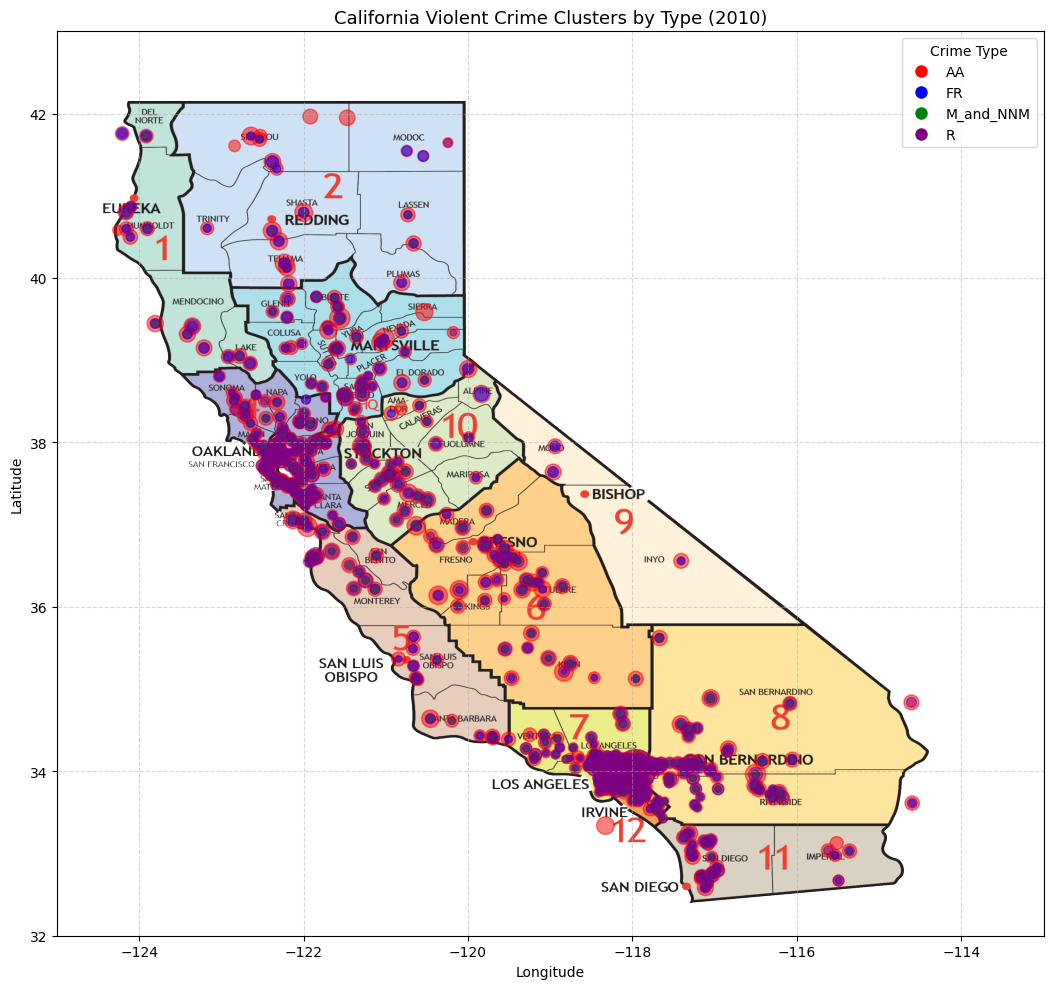

In [15]:
crime_categories = ["AA", "FR", "M_and_NNM", "R"]
crime_colors = {"AA": "red", "FR": "blue", "M_and_NNM": "green", "R": "purple"}

# Load background image of California
bg_img = mpimg.imread("California_Map2.png")

def plot_crime_clusters(year):
    filtered = df_geo[df_geo["reportyear"] == year]

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(bg_img, extent=[-124.45, -114.40, 32.40, 42.15], aspect='equal')

    # Plot each crime category
    for crime in crime_categories:
        subset = filtered[filtered[crime] > 0]
        ax.scatter(
            subset["lon"],
            subset["lat"],
            s=np.sqrt(subset[crime]) * 2000,  # Adjust scale as needed
            c=crime_colors[crime],
            alpha=0.5,
            label=crime
        )

    # Set map limits and labels
    ax.set_xlim(-125, -113)
    ax.set_ylim(32, 43)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"California Violent Crime Clusters by Type ({year})", fontsize=13)

    # Create cleaner legend with just color markers
    handles = [Line2D([0], [0], marker='o', color='w', label=label,
                      markerfacecolor=color, markersize=10)
               for label, color in crime_colors.items()]
    ax.legend(handles=handles, title="Crime Type")

    
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Example usage
plot_crime_clusters(2010)

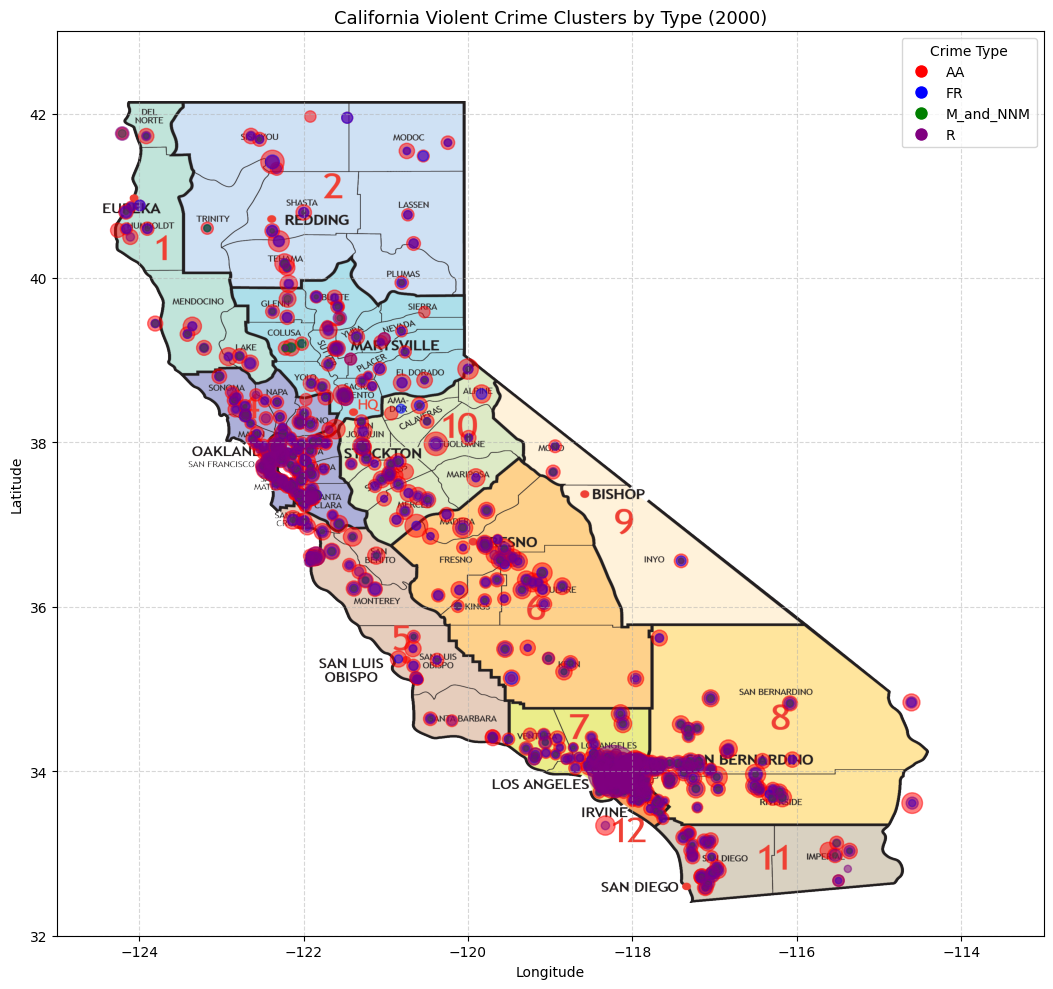

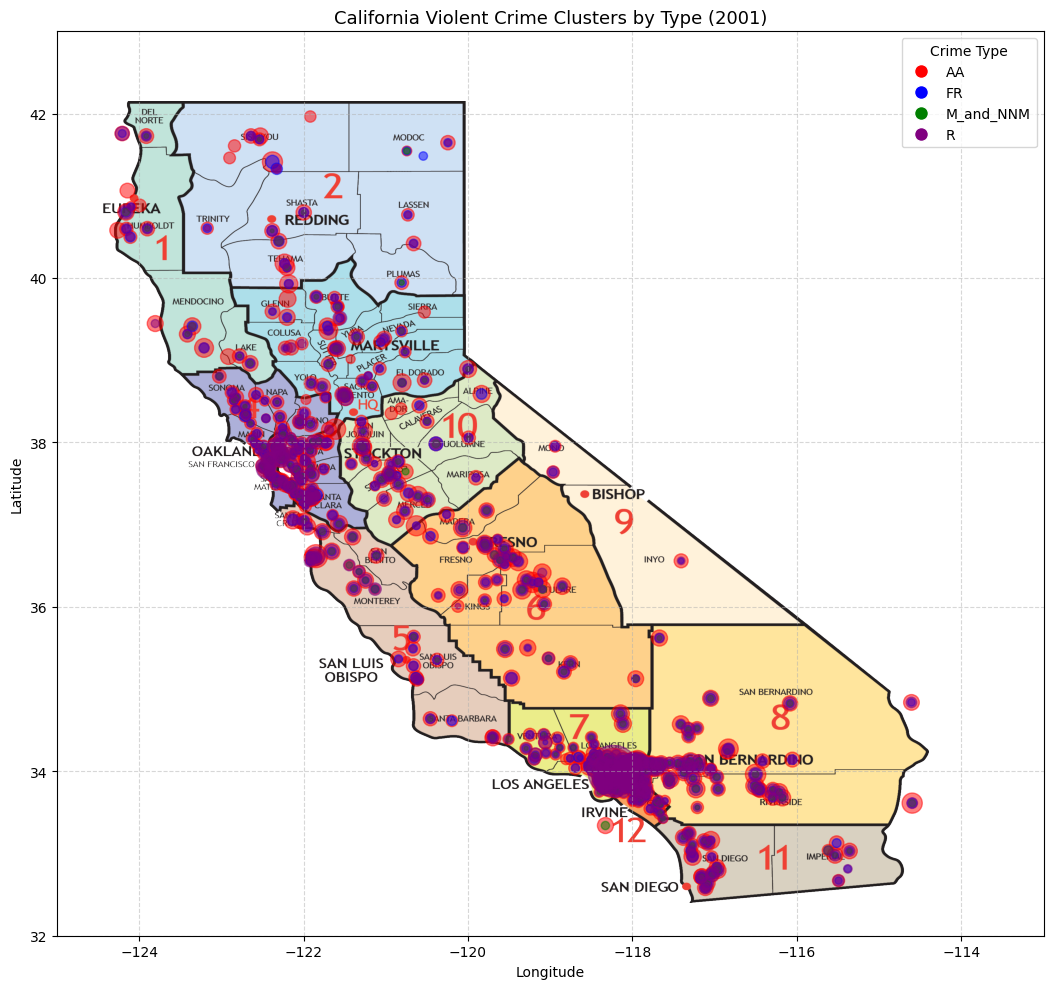

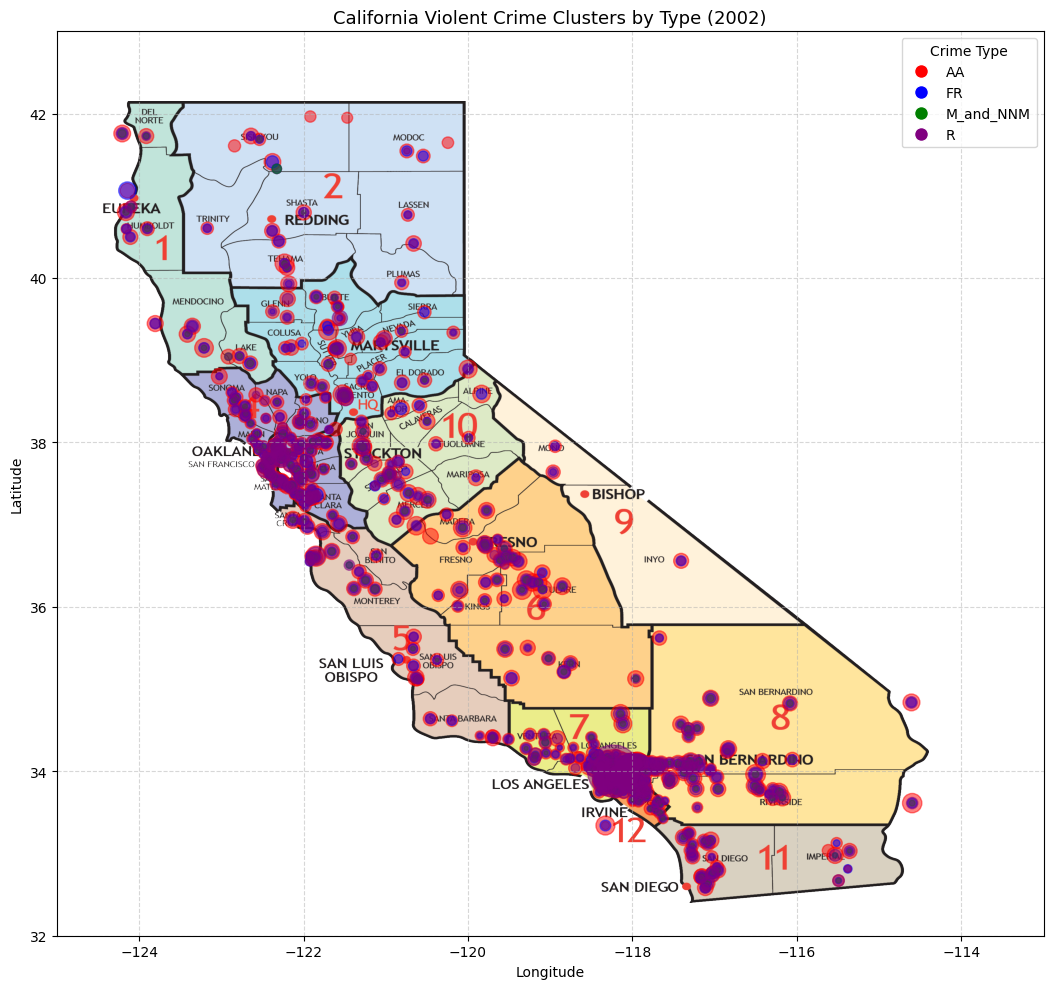

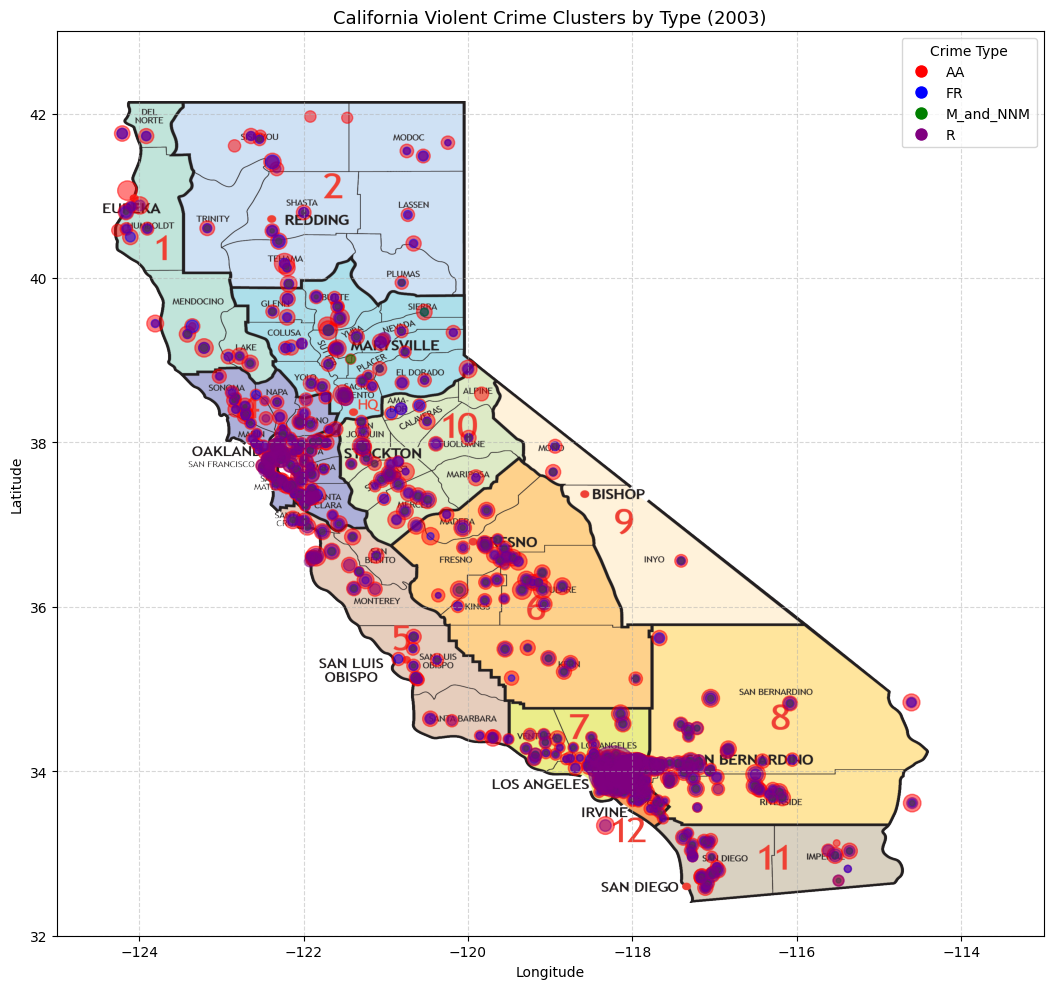

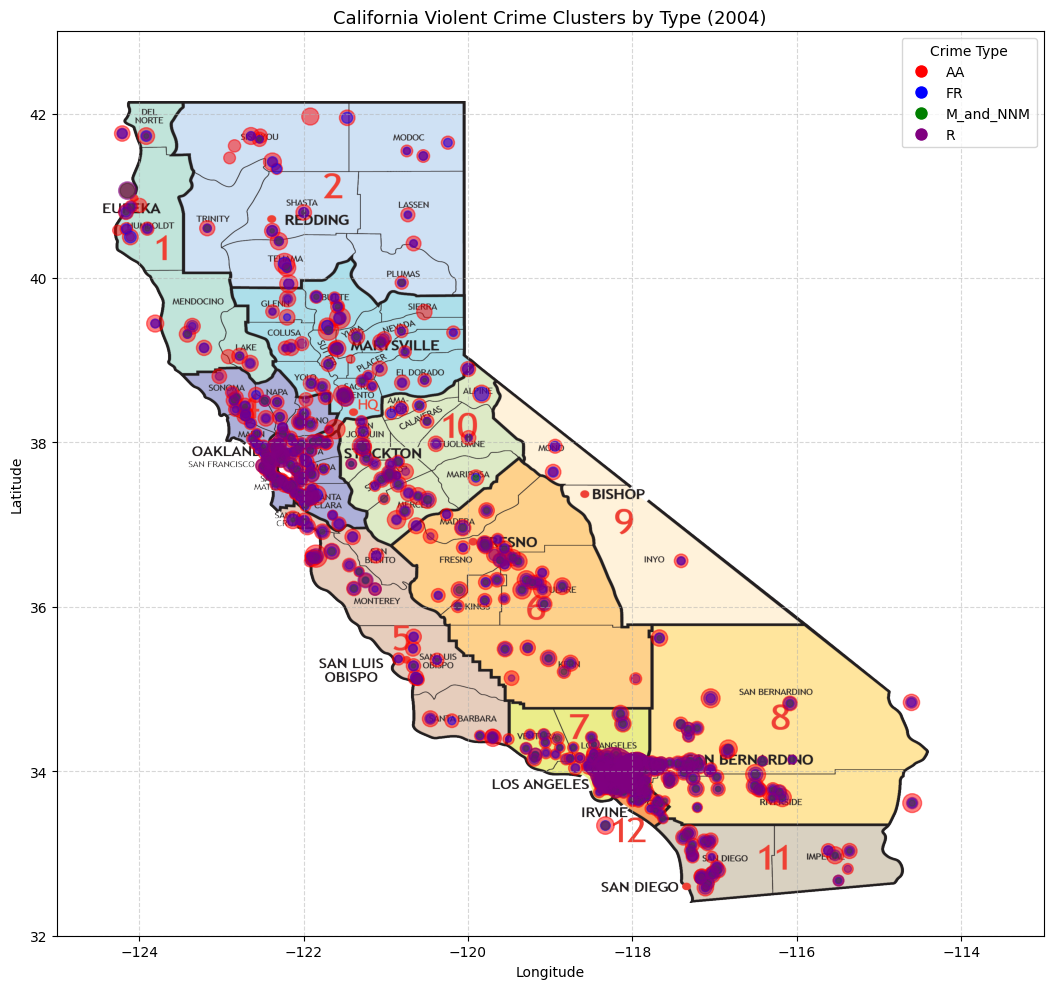

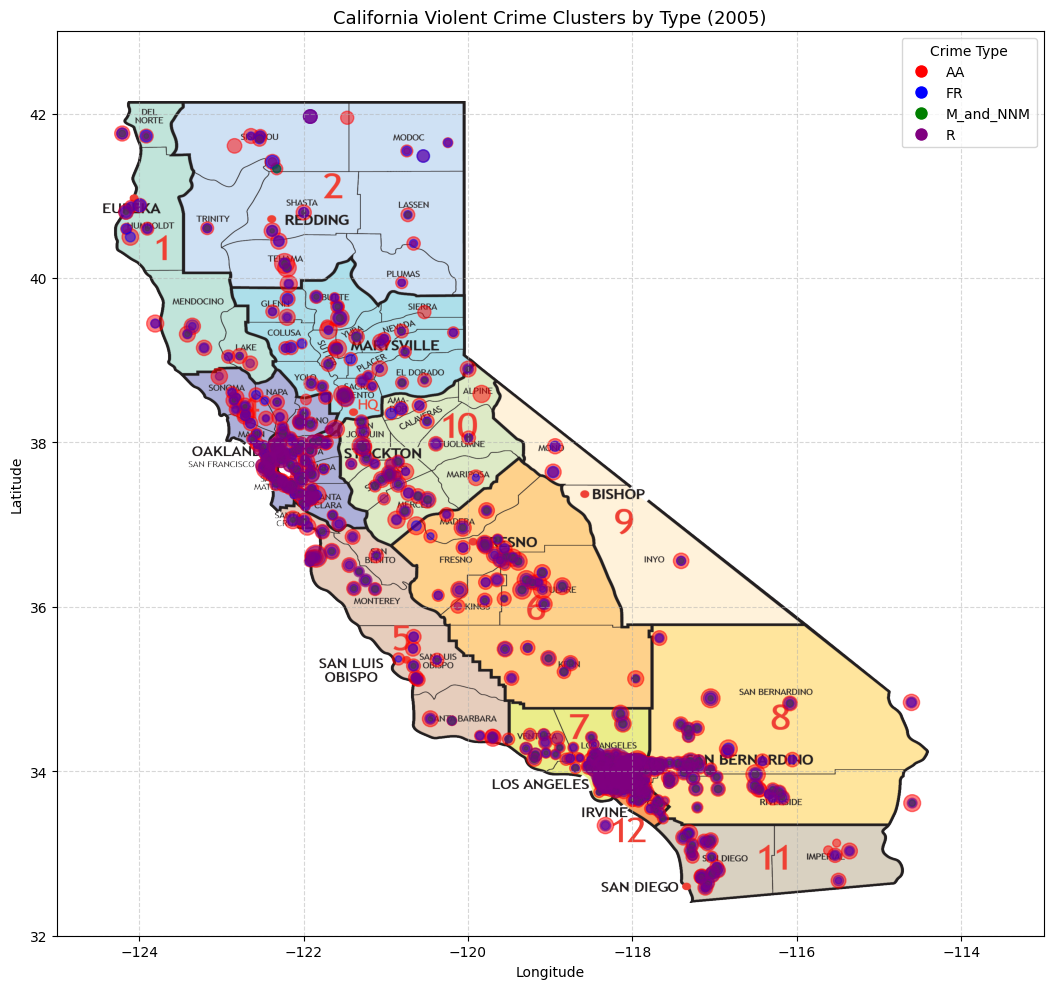

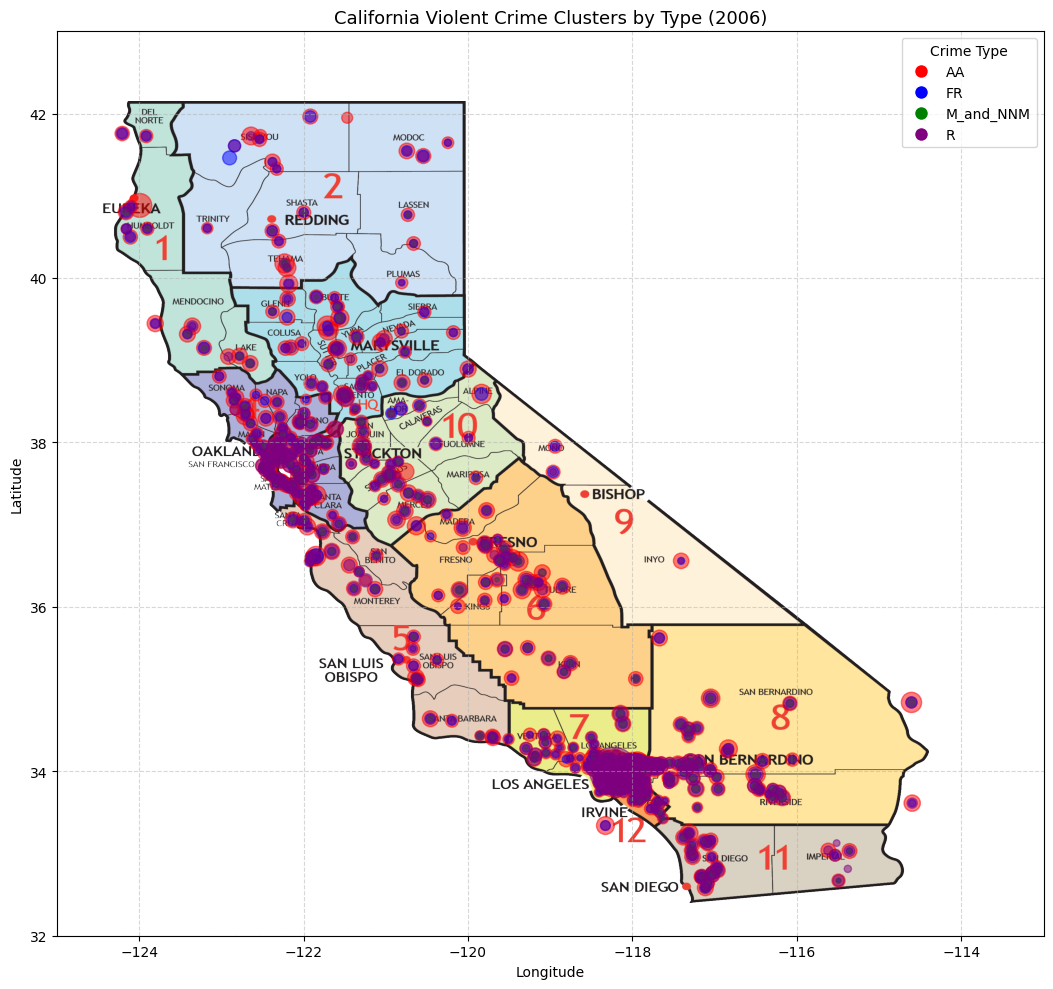

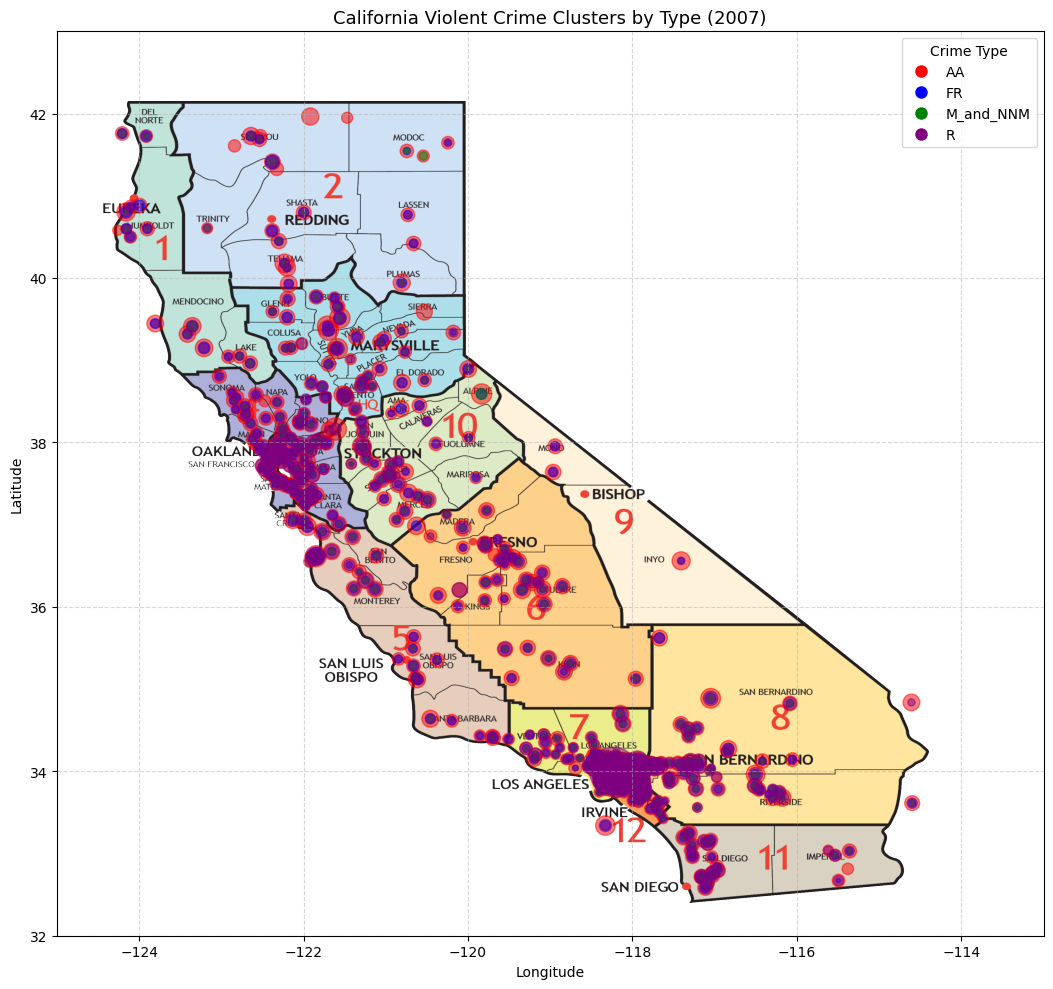

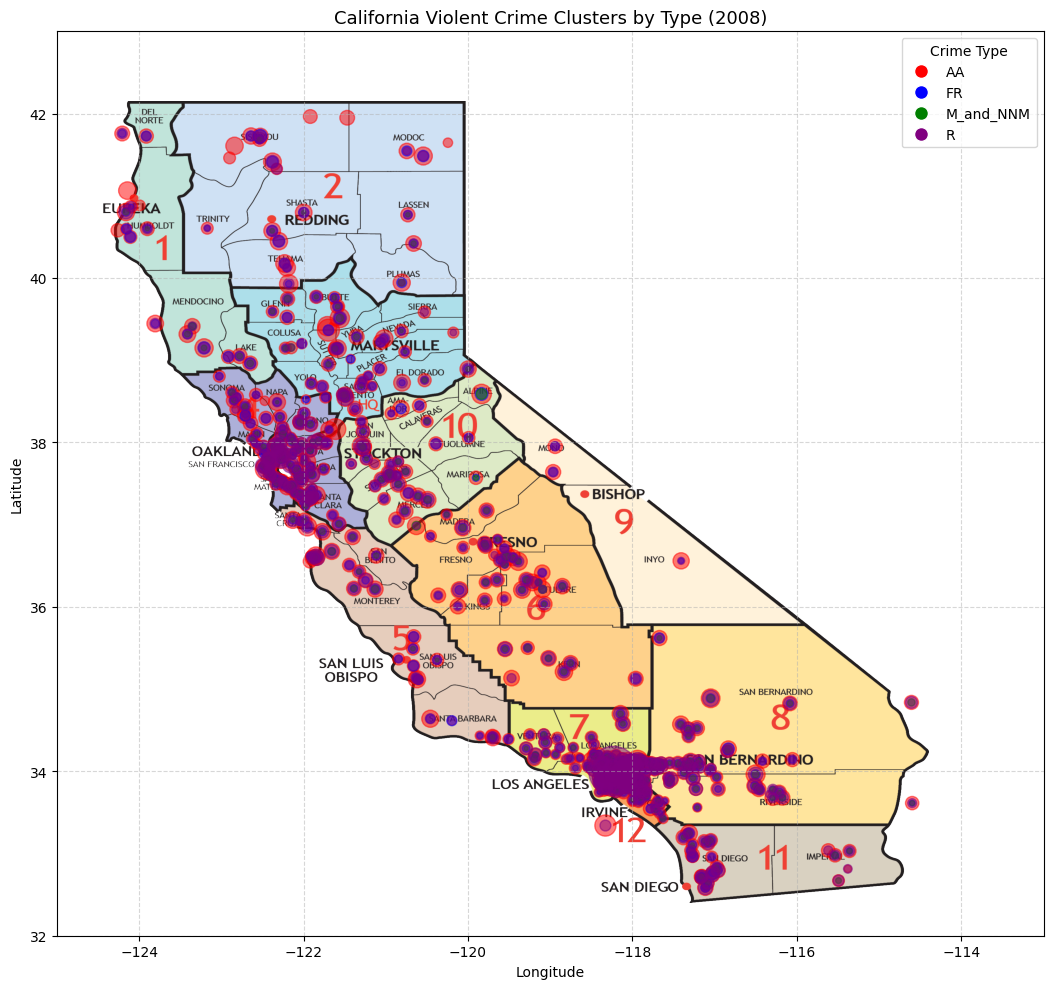

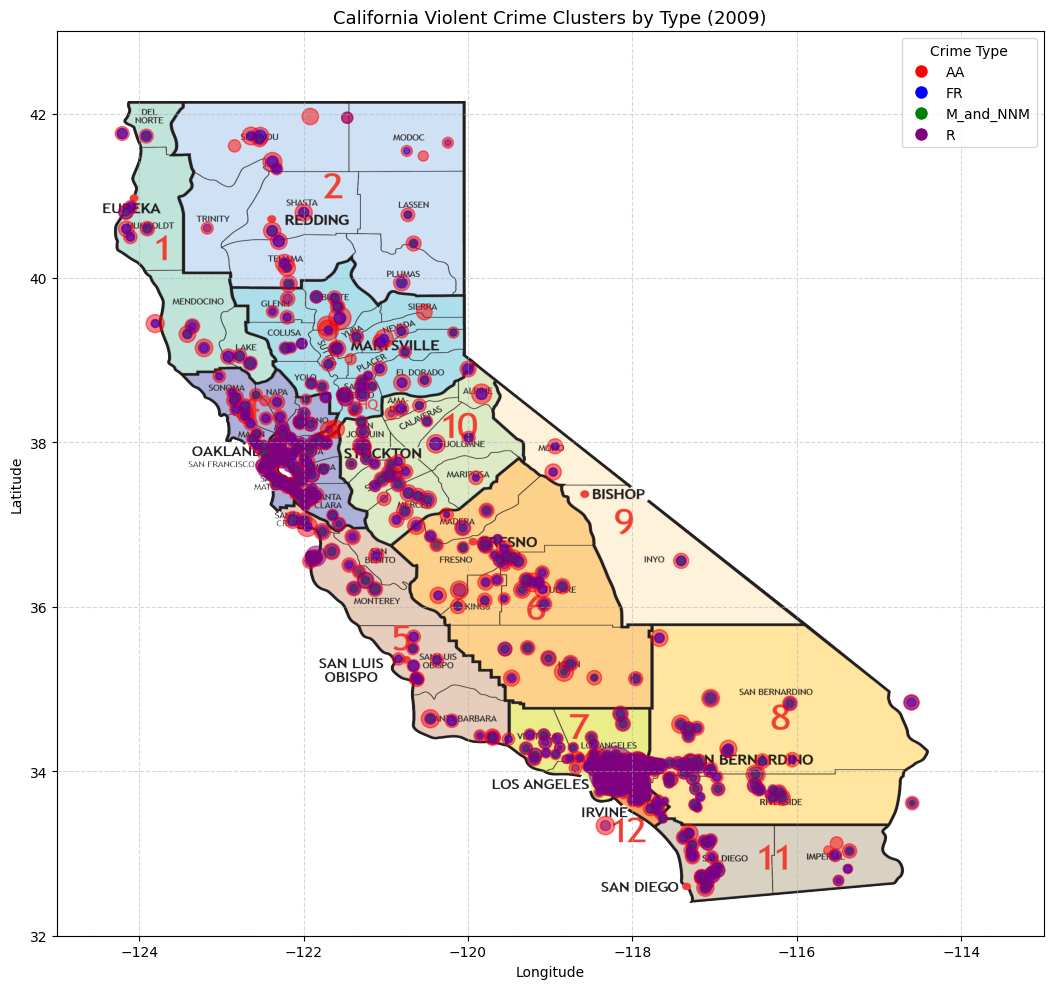

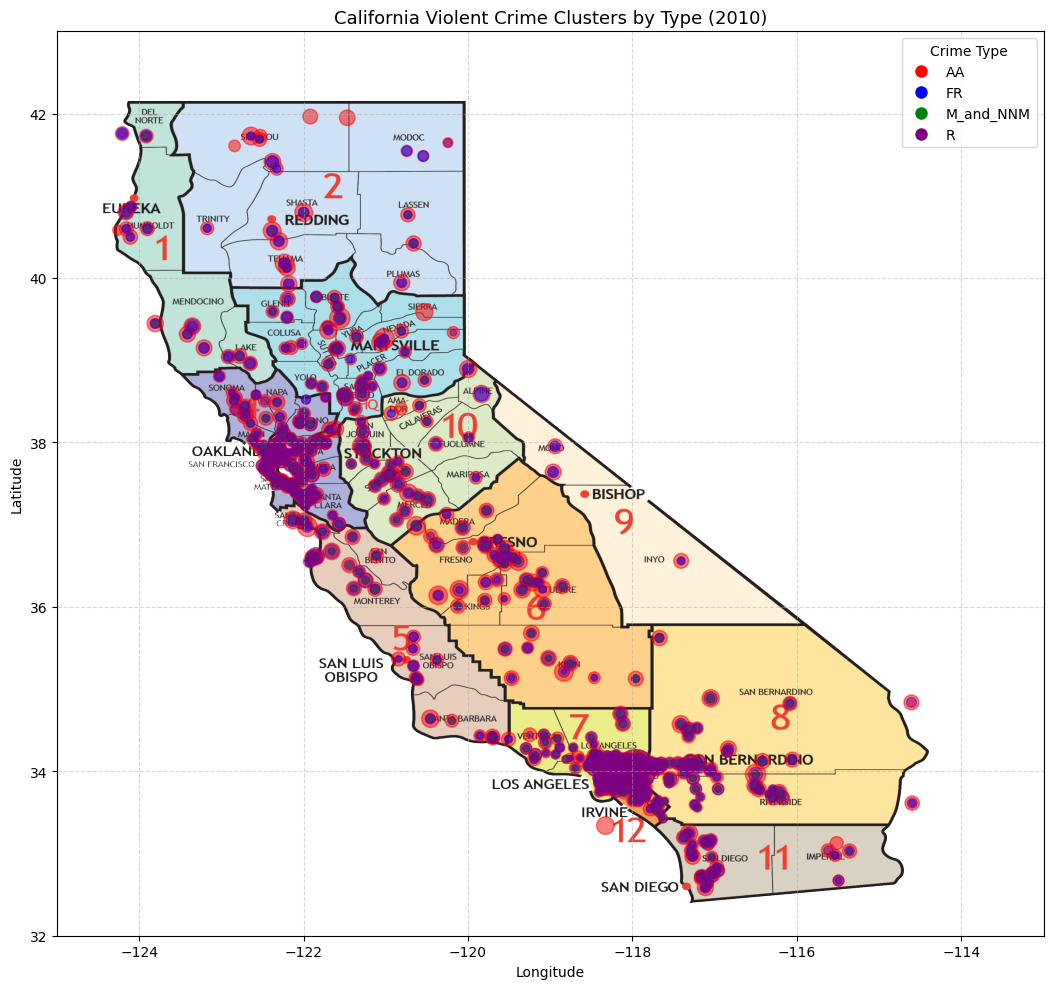

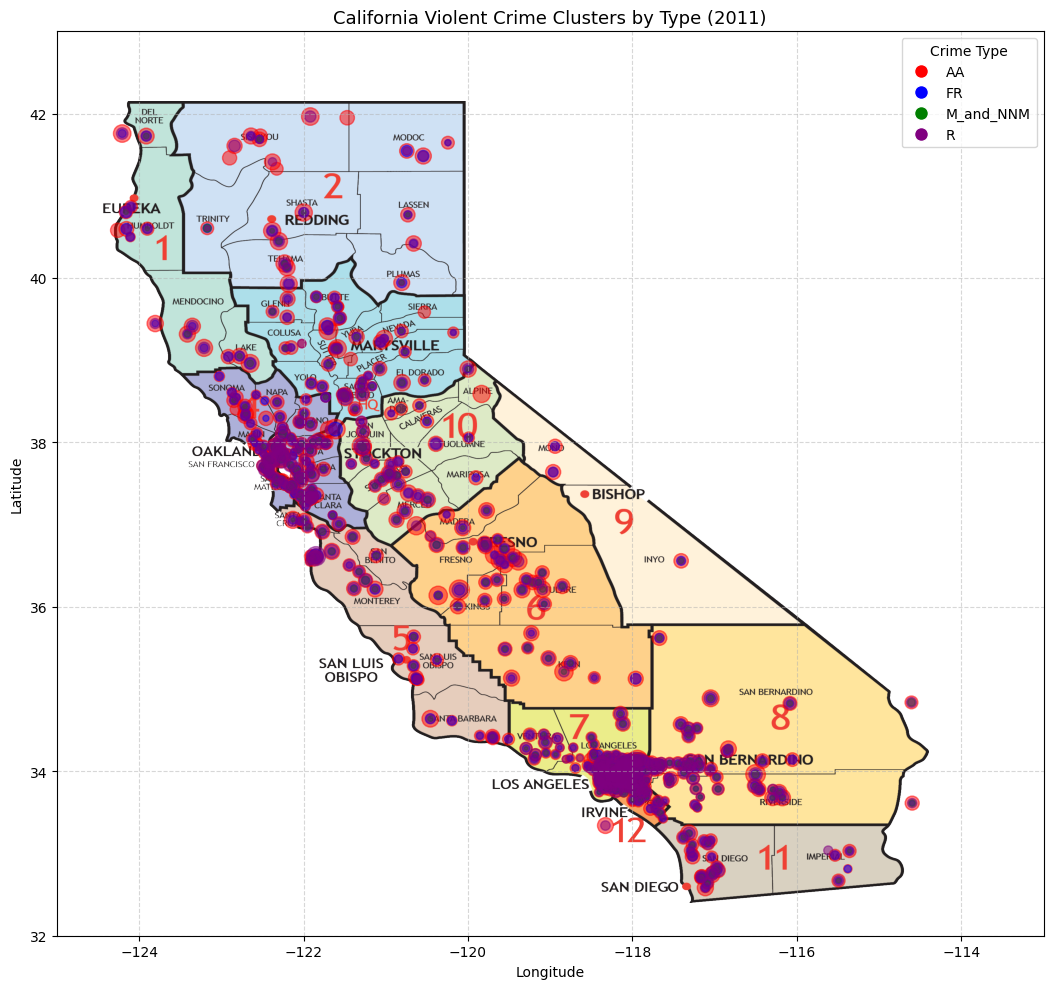

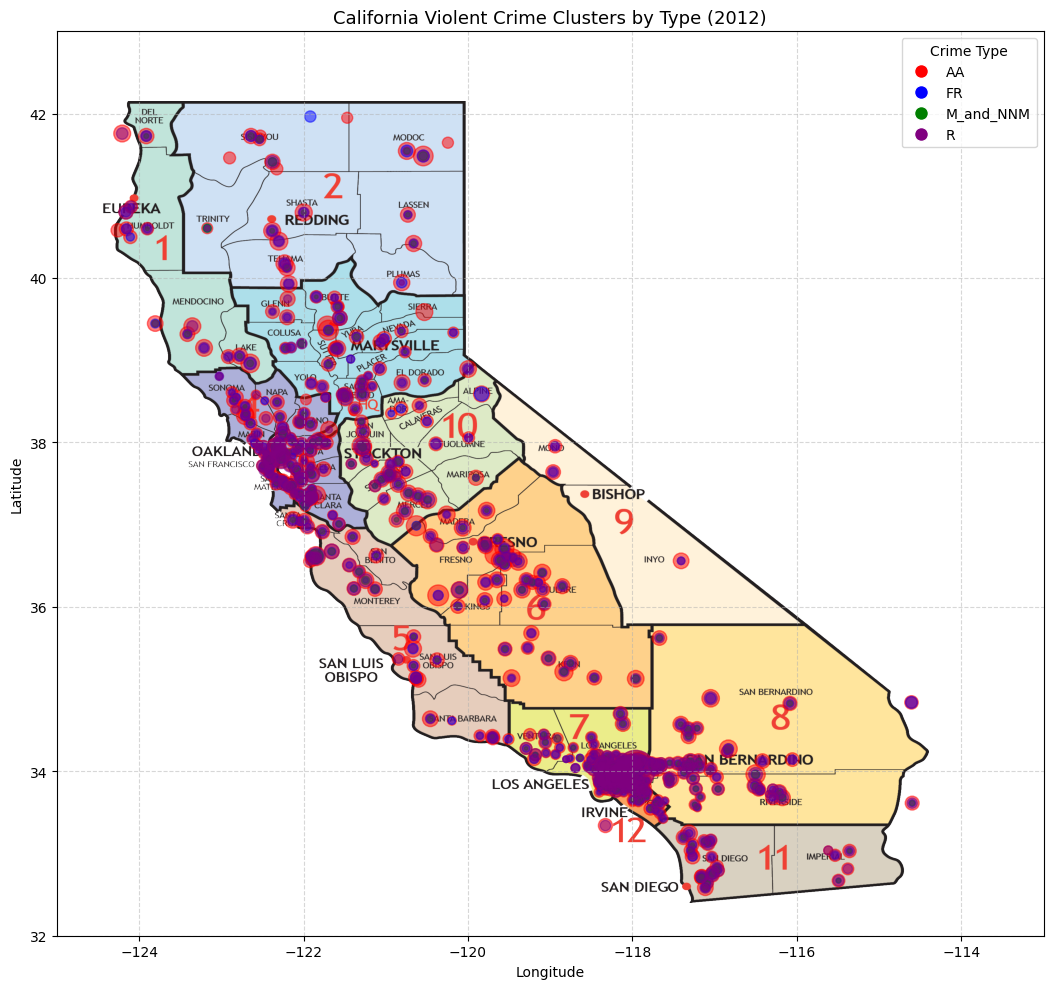

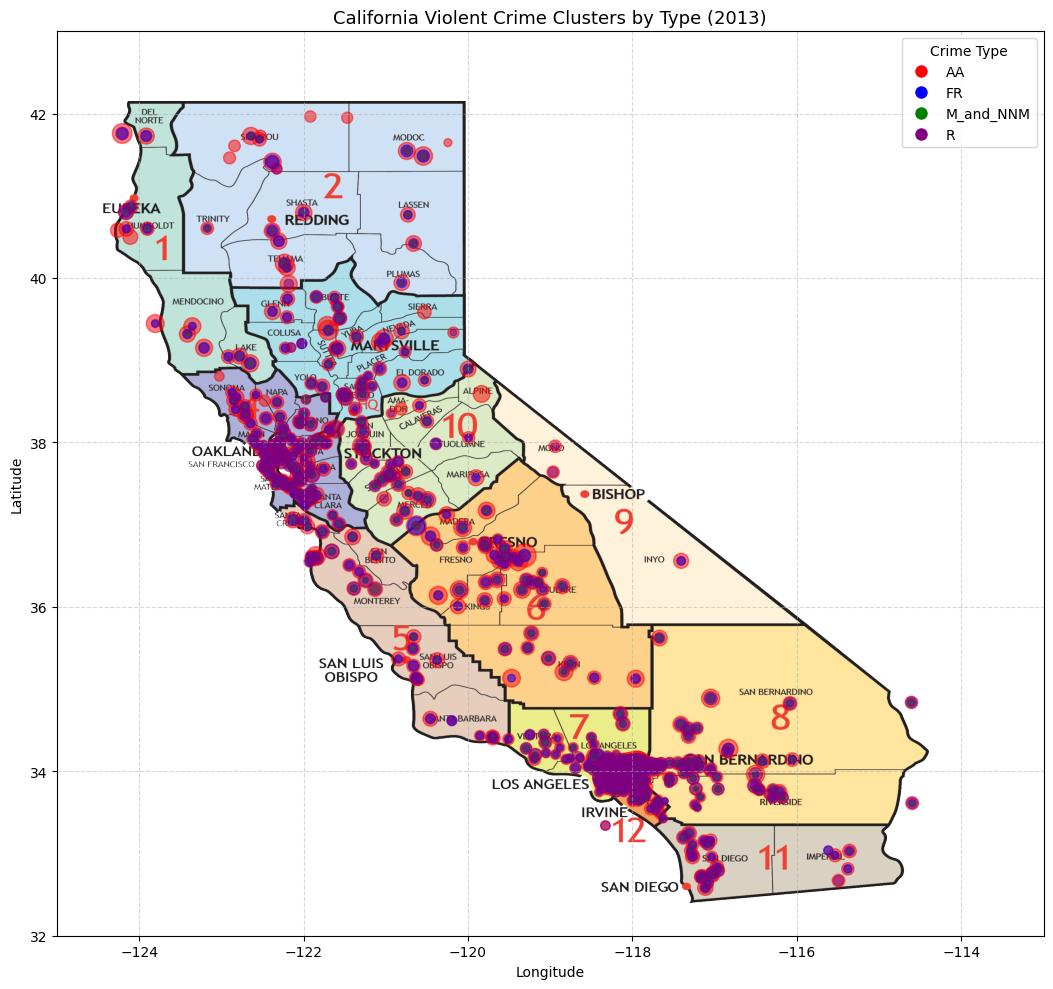

<Figure size 640x480 with 0 Axes>

In [16]:
for year in range(2000, 2014):
    plot_crime_clusters(year)

plt.tight_layout()
plt.show()

# 5. Exploratory Data Analysis (EDA) for Machine Learning

In this section, we analyze the data to prepare it for machine learning tasks including:
- **K-Means Clustering**: To detect natural groups of regions or crime patterns.
- **K-Nearest Neighbors (KNN)**: To predict labels based on proximity in feature space.
- **Principal Component Analysis (PCA)**: To reduce dimensionality and identify the most informative features.

We will explore feature distributions, potential cluster structures, class separability, and dimensionality.


In [24]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# General overview
print(df_geo.info())
print(df_geo.describe())

# Null values
print(df_geo.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7127 entries, 0 to 7126
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reportyear      7127 non-null   int64  
 1   geoname         7127 non-null   object 
 2   geotypevalue    7127 non-null   int64  
 3   county_name     7127 non-null   object 
 4   county_fips     7127 non-null   int64  
 5   region_name     7127 non-null   object 
 6   region_code     7127 non-null   int64  
 7   dof_population  7127 non-null   int64  
 8   AA              7127 non-null   float64
 9   FR              7127 non-null   float64
 10  M_and_NNM       7127 non-null   float64
 11  R               7127 non-null   float64
 12  VCT             7127 non-null   float64
 13  rate            7127 non-null   float64
 14  lat             7127 non-null   float64
 15  lon             7127 non-null   float64
dtypes: float64(8), int64(5), object(3)
memory usage: 891.0+ KB
None
        report

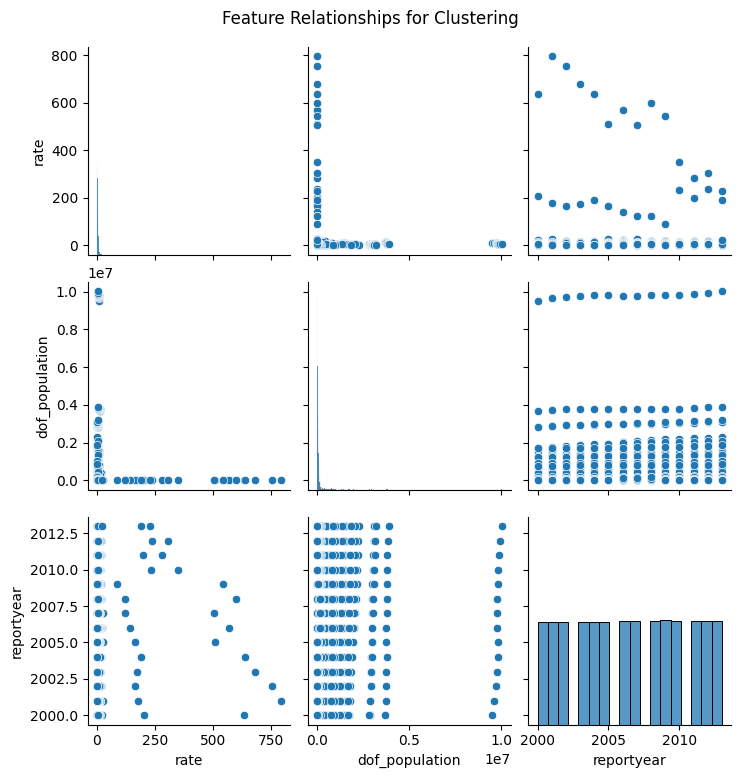

In [32]:
# Pairplot of selected numerical features
features_for_clustering = ['rate', 'dof_population', 'reportyear']

sns.pairplot(df_geo[features_for_clustering])
plt.suptitle("Feature Relationships for Clustering", y=1.03)
plt.show()


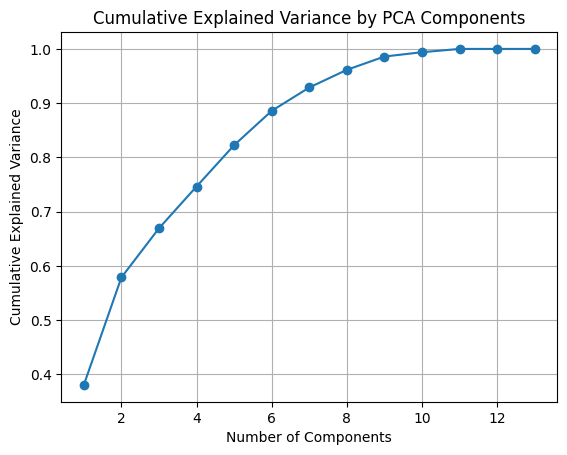

[0.38056237 0.57867958 0.66932926 0.74636469 0.82255217 0.88581733
 0.92888136 0.96146178 0.98594783 0.99395591 0.99999999 1.
 1.        ]


In [34]:
numeric_cols = df_geo.select_dtypes(include='number').columns
# Use all numeric features for PCA
X = df_geo[numeric_cols].dropna()  # Drop rows with missing values (or fill)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot cumulative variance
import matplotlib.pyplot as plt

plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()
print(pca.explained_variance_ratio_.cumsum())



### Observations from EDA

- The numeric features such as `violent_crimes`, `dof_population`, and `unemployment_rate` show moderate correlation and some potential for clustering. Counties with high population often have higher total violent crime counts, but normalizing by population reveals more nuanced patterns.
  
- The PCA output enlights us the following:

    - The first component explains 38.06% of the variance in the data.

    - The second component, when added, explains a cumulative 57.87% of the variance.

    - By the 11th component, nearly 100% of the variance is explained, and after the 12th component, the cumulative variance stops increasing, remaining at 1, indicating that all the variance is captured.

- This suggests that the data can be effectively reduced to a smaller number of components without losing much information. For example, the first 5 components could be retained to explain around 82.26% of the variance.